In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    average_precision_score
)
from sklearn.utils import shuffle

# Imports pour le multiprocessing
import multiprocessing
from tqdm import tqdm

# --- NOTRE NOUVEL IMPORT BLS ---
from src.features_bls import generate_bls_features

print("Bibliothèques importées.")

Bibliothèques importées.


In [2]:
print("Chargement et mélange des données brutes...")
train_df = pd.read_csv('../data/raw/train.csv')

X_raw = train_df.drop('LABEL', axis=1).values
y = train_df['LABEL'].values - 1  # (0, 1)

X_raw_shuffled, y_shuffled = shuffle(X_raw, y, random_state=42)
print("Données chargées et mélangées.")

Chargement et mélange des données brutes...
Données chargées et mélangées.


In [3]:
# Cellule 3 : Génération des Features BLS

X_data_to_process = X_raw_shuffled

print(f"Démarrage de la génération des features BLS (4 par étoile)...")

N_CORES = multiprocessing.cpu_count() - 1
if N_CORES < 1: N_CORES = 1
print(f"Utilisation de {N_CORES} cœurs CPU...")

with multiprocessing.Pool(processes=N_CORES) as pool:
    # pool.map fonctionne car notre fonction n'a qu'un seul argument
    X_features_list = list(tqdm(pool.map(generate_bls_features, X_data_to_process), total=len(X_data_to_process)))

# Convertir la liste de résultats en array numpy
X_features = np.array(X_features_list)
y = y_shuffled

print("Génération des features BLS terminée !")
print(f"Forme de X_features : {X_features.shape}")

Démarrage de la génération des features BLS (4 par étoile)...
Utilisation de 7 cœurs CPU...


100%|██████████| 5087/5087 [00:00<00:00, 2799688.29it/s]

Génération des features BLS terminée !
Forme de X_features : (5087, 4)


In [4]:
# Cellule 4 : DataFrame Creation

feature_names = ['peak_snr', 'depth', 'duration', 'period']
df = pd.DataFrame(X_features, columns=feature_names)
df['label'] = y

print("Aperçu du DataFrame de features BLS :")
print(df.head())

print("\nDescription statistique (Toutes les étoiles) :")
print(df.describe())

print("\nDescription statistique (Seulement les Planètes) :")
print(df[df['label'] == 1].describe())

Aperçu du DataFrame de features BLS :
   peak_snr  depth  duration  period  label
0       0.0    0.0       0.0     0.0      0
1       0.0    0.0       0.0     0.0      0
2       0.0    0.0       0.0     0.0      1
3       0.0    0.0       0.0     0.0      0
4       0.0    0.0       0.0     0.0      0

Description statistique (Toutes les étoiles) :
       peak_snr   depth  duration  period        label
count    5087.0  5087.0    5087.0  5087.0  5087.000000
mean        0.0     0.0       0.0     0.0     0.007273
std         0.0     0.0       0.0     0.0     0.084982
min         0.0     0.0       0.0     0.0     0.000000
25%         0.0     0.0       0.0     0.0     0.000000
50%         0.0     0.0       0.0     0.0     0.000000
75%         0.0     0.0       0.0     0.0     0.000000
max         0.0     0.0       0.0     0.0     1.000000

Description statistique (Seulement les Planètes) :
       peak_snr  depth  duration  period  label
count      37.0   37.0      37.0    37.0   37.0
mean   

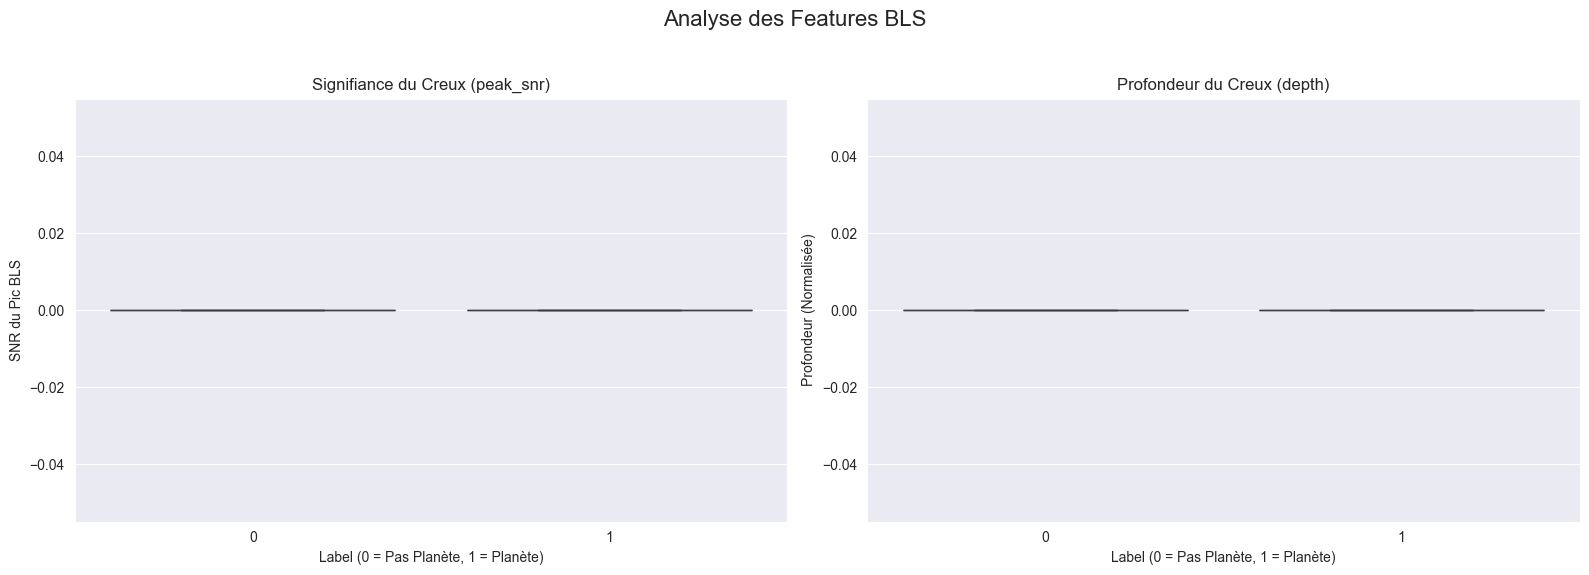

In [5]:
# Cellule 5 : Sanity check

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.suptitle("Analyse des Features BLS", fontsize=16)

# Graphique 1 : La "Signifiance" du pic (SNR)
sns.boxplot(ax=axes[0], x='label', y='peak_snr', data=df)
axes[0].set_title('Signifiance du Creux (peak_snr)')
axes[0].set_xlabel("Label (0 = Pas Planète, 1 = Planète)")
axes[0].set_ylabel("SNR du Pic BLS")

# Graphique 2 : La "Profondeur" du creux
sns.boxplot(ax=axes[1], x='label', y='depth', data=df)
axes[1].set_title('Profondeur du Creux (depth)')
axes[1].set_xlabel("Label (0 = Pas Planète, 1 = Planète)")
axes[1].set_ylabel("Profondeur (Normalisée)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# (Hypothèse : Les boîtes "1" devraient être TRÈS différentes des "0")

In [6]:
# Cellule 6 : Train/Test Split

print("Division des données (features BLS)...")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, # <-- Nos 4 features BLS
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Forme X_train : {X_train.shape}")

Division des données (features BLS)...
Forme X_train : (4069, 4)


In [7]:
# Cellule 7 : Training RF classifier

print("Entraînement du Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', # Gère l'imbalance
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement du Random Forest Classifier...
Entraînement terminé.


In [8]:
# Cells 8 : Analysis (v24 - BLS)

print("Évaluation du modèle Random Forest (BLS)...")

y_pred_class = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print("ÉVALUATION FINALE (Random Forest + BLS)")
print("="*40)

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred_class, target_names=['Pas Planète', 'Planète']))

print("\n--- Matrice de Confusion ---")
print(confusion_matrix(y_test, y_pred_class))

pr_auc_score = average_precision_score(y_test, y_pred_proba)
print(f"\nScore PR-AUC global (Average Precision) : {pr_auc_score:.4f}")

Évaluation du modèle Random Forest (BLS)...

ÉVALUATION FINALE (Random Forest + BLS)

--- Rapport de Classification ---
              precision    recall  f1-score   support

 Pas Planète       0.99      1.00      1.00      1011
     Planète       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.99      0.99      0.99      1018


--- Matrice de Confusion ---
[[1011    0]
 [   7    0]]

Score PR-AUC global (Average Precision) : 0.0069


C:\Users\libra\IdeaProjects\exoplanet-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\libra\IdeaProjects\exoplanet-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\libra\IdeaProjects\exoplanet-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(